# Visualization


In [2]:
# Import necessary modules
from os import makedirs, path
from atlasreader import get_statmap_info
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from nilearn import image, plotting, reporting
from scipy import stats
from scipy.stats import pearsonr
import os, fnmatch
from glob import glob
from pathlib import Path
import re
import matplotlib as mpl
from nilearn import plotting, image
import numpy as np
from nimare import correct, io, meta, utils
import os
import nibabel as nib
from nilearn.image import get_data

# print the current working directory
# print(os.getcwd())

The Python package you are importing, AtlasReader, is licensed under the
BSD-3 license; however, the atlases it uses are separately licensed under more
restrictive frameworks.
By using AtlasReader, you agree to abide by the license terms of the
individual atlases. Information on these terms can be found online at:
https://github.com/miykael/atlasreader/tree/master/atlasreader/data



INFO:arviz:Found 'auto' as default backend, checking available backends
INFO:arviz:Matplotlib is available, defining as default backend
INFO:arviz.preview:arviz_base available, exposing its functions as part of arviz.preview
INFO:arviz.preview:arviz_stats available, exposing its functions as part of arviz.preview
INFO:arviz.preview:arviz_plots available, exposing its functions as part of arviz.preview


In [ ]:
# File path definitions
# Contrast maps (unthresholded z-maps)
patient_greater_control = "../3_Output/2_Contrast/patient_greater_control_z.nii.gz"
control_greater_patient = "../3_Output/2_Contrast/control_greater_patient_z.nii.gz"

# Single ALE maps (unthresholded z-maps)
ale_hyper = "../3_Output/1_ALE/hyperactivation_z.nii.gz"
ale_hypo  = "../3_Output/1_ALE/hypoactivation_z.nii.gz"

# Helper functions 
def get_peak_info(img_path):
    """Return peak voxel value and its MNI coordinate."""
    img = nib.load(img_path)
    data = img.get_fdata()
    idx = np.unravel_index(np.argmax(np.abs(data)), data.shape)
    peak_value = data[idx]
    affine = img.affine
    peak_mni = tuple(np.round(nib.affines.apply_affine(affine, idx)).astype(int))
    return {"peak_value": peak_value, "peak_mni": peak_mni}

def get_z_statistics(img_path):
    """Return descriptive statistics for non-zero voxels."""
    img = nib.load(img_path)
    data = img.get_fdata()
    nonzero = data[data != 0]
    return {
        "mean": float(np.mean(np.abs(nonzero))),
        "std":  float(np.std(np.abs(nonzero))),
        "min":  float(np.min(nonzero)),
        "max":  float(np.max(nonzero)),
        "n_voxels": int(len(nonzero)),
    }

print("Path variables and helper functions defined.")


Path variables and helper functions defined.



Unified display range: vmin=-5.23, vmax=5.23



Processing: Contrast: Patient > Control
Image: ../3_Output/2_Contrast/patient_greater_control_z.nii.gz


/var/folders/yk/78rqxlxn4pz_rsb5_31xvh340000gn/T/ipykernel_3239/2360746305.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: ../3_Output/2_Contrast/Contrast_Patient_gt_Control_improved.png


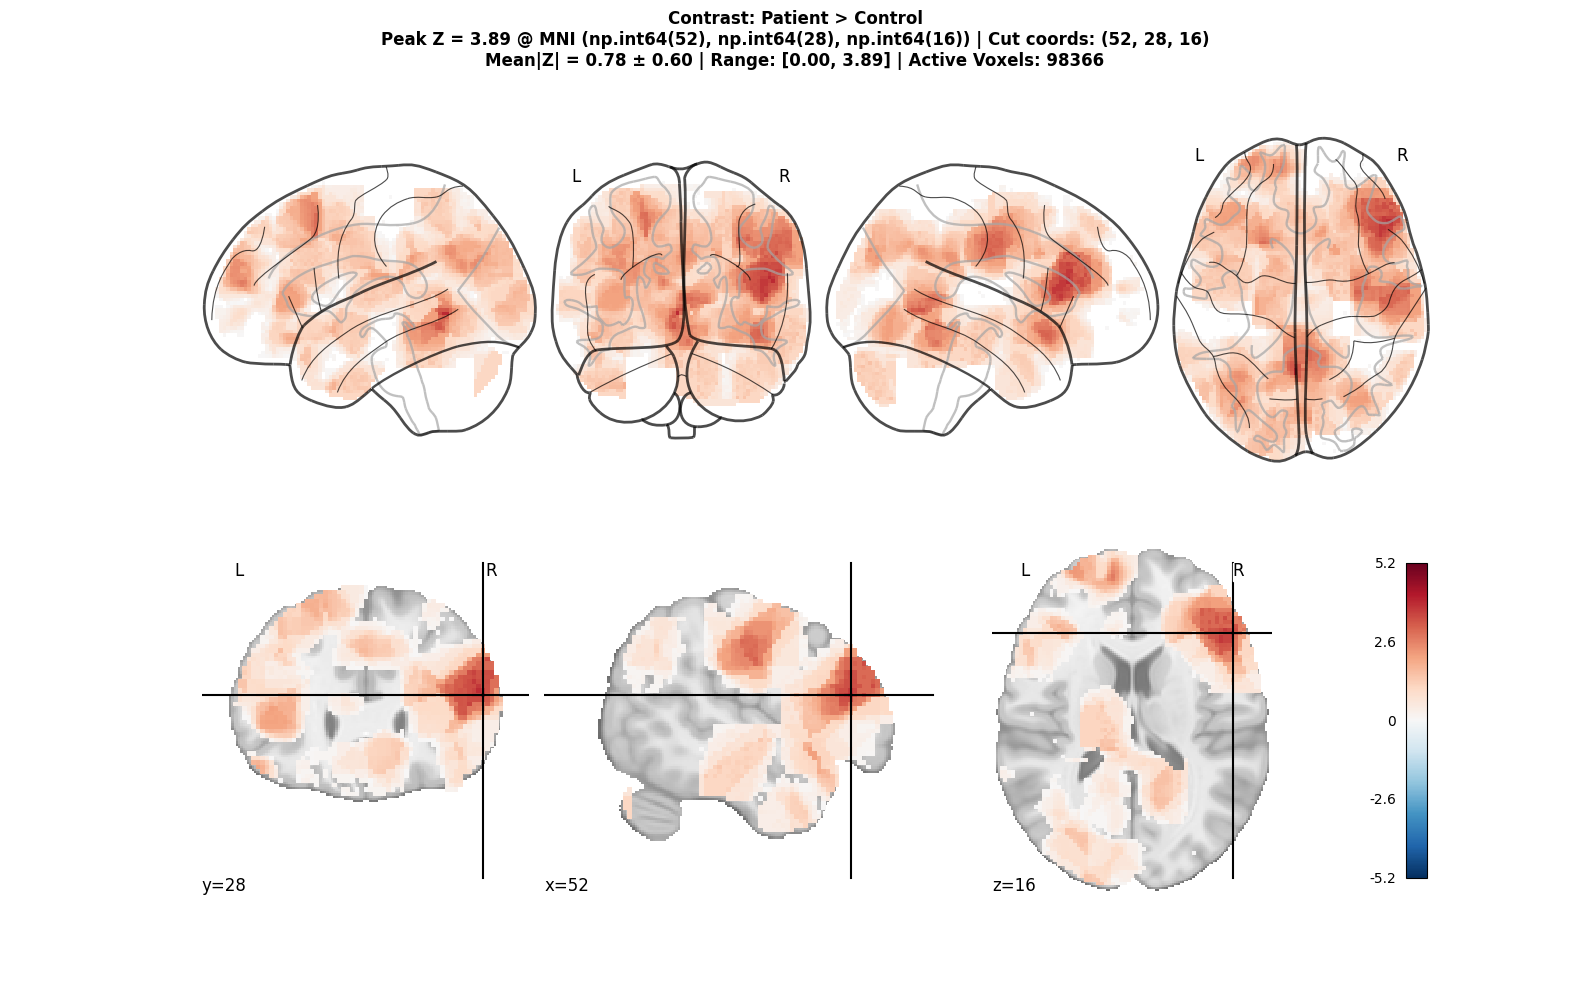


Contrast: Patient > Control
Peak Info:
  Z-value   : 3.891
  MNI coord : (np.int64(52), np.int64(28), np.int64(16))

Z-value Statistics (non-zero voxels):
  Mean Z   : 0.779
  Std Dev  : 0.600
  Min Z    : 0.000
  Max Z    : 3.891
  N Voxels : 98366


Processing: Contrast: Control > Patient
Image: ../3_Output/2_Contrast/control_greater_patient_z.nii.gz
Saved: ../3_Output/2_Contrast/Contrast_Control_gt_Patient_improved.png


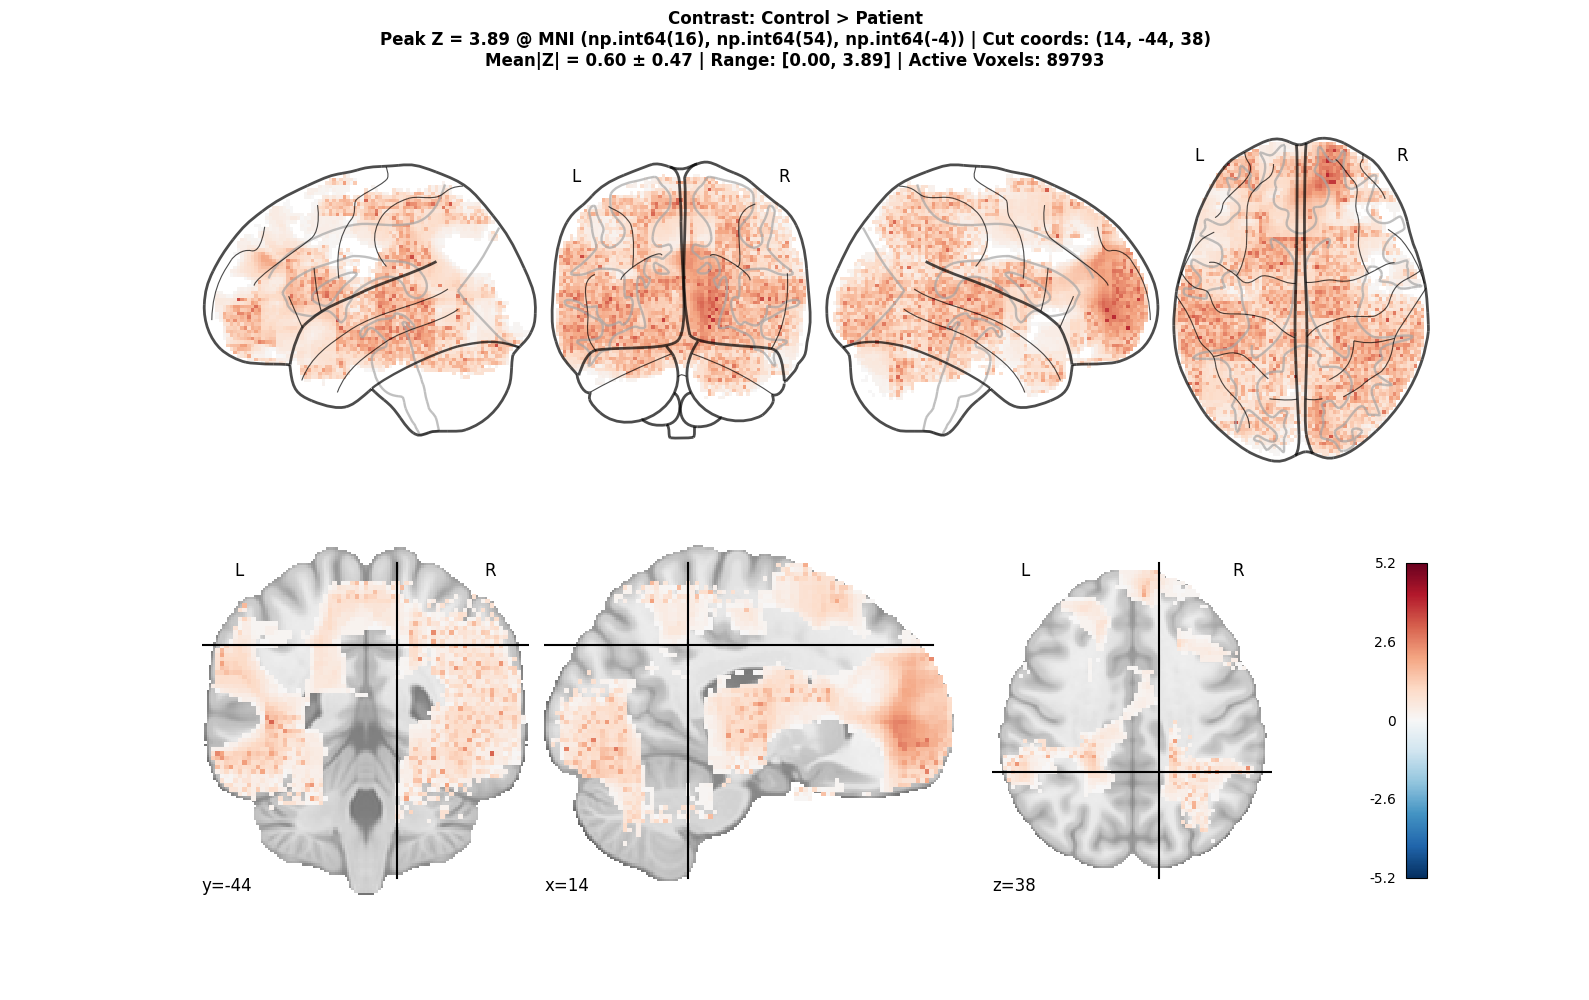


Contrast: Control > Patient
Peak Info:
  Z-value   : 3.891
  MNI coord : (np.int64(16), np.int64(54), np.int64(-4))

Z-value Statistics (non-zero voxels):
  Mean Z   : 0.595
  Std Dev  : 0.469
  Min Z    : 0.000
  Max Z    : 3.891
  N Voxels : 89793


Processing: Single ALE: Hyperactivation (Patient > Control)
Image: ../3_Output/1_ALE/hyperactivation_z.nii.gz
Saved: ../3_Output/2_Contrast/Single_ALE_Hyperactivation_(Patient_gt_Control)_improved.png


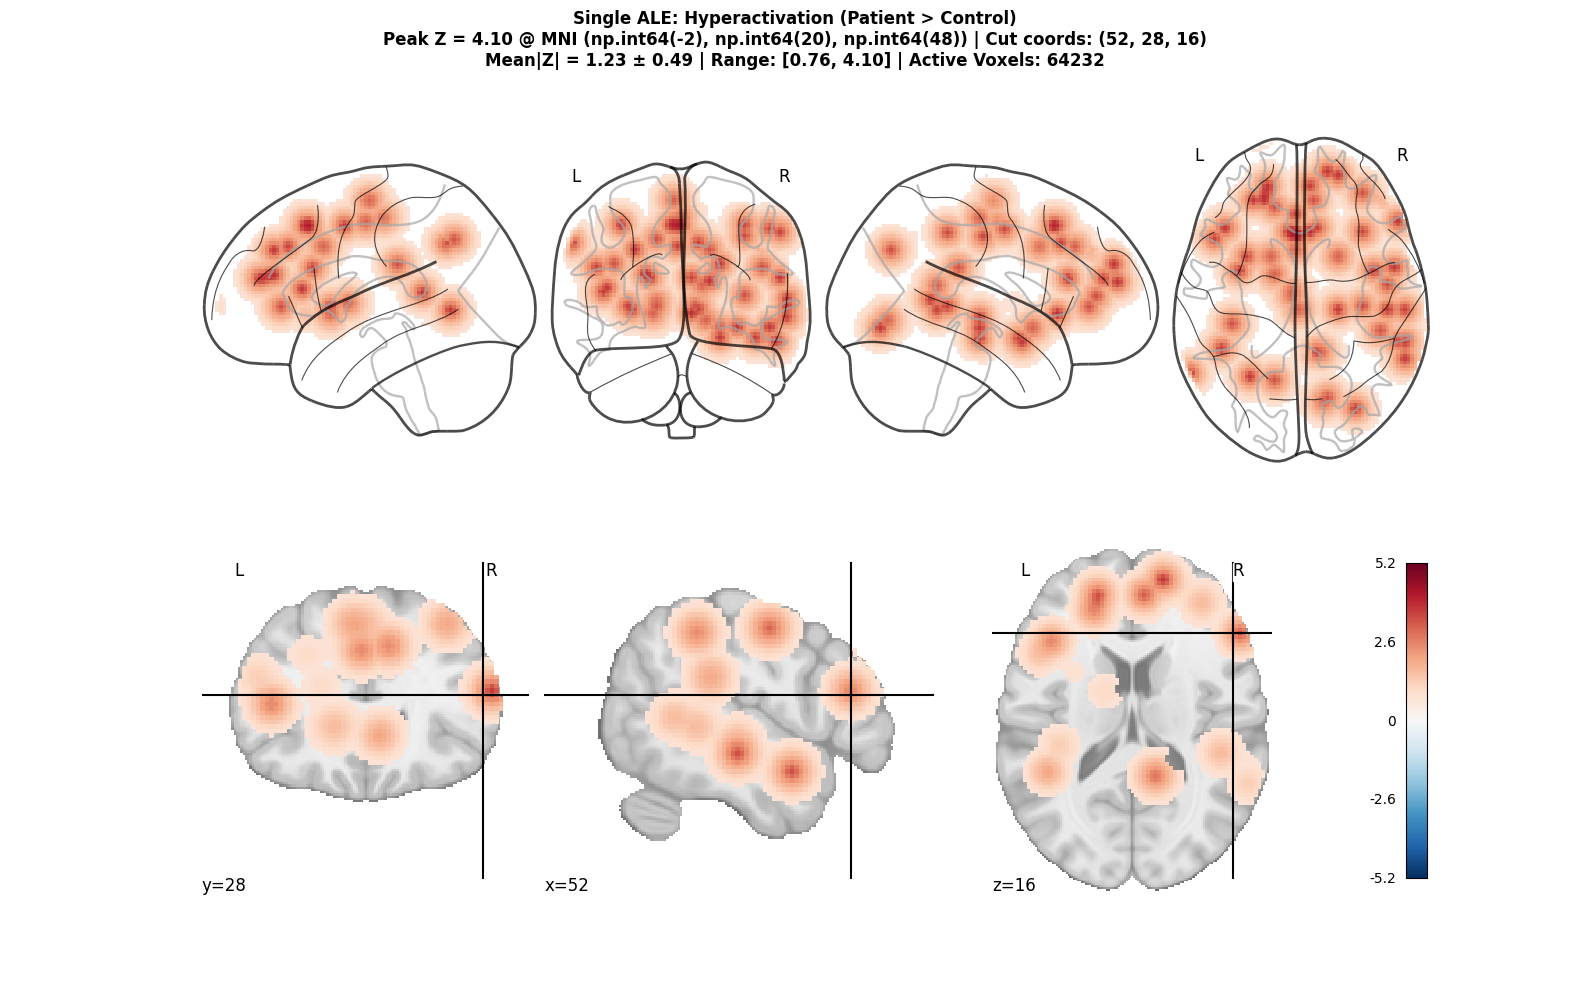


Single ALE: Hyperactivation (Patient > Control)
Peak Info:
  Z-value   : 4.095
  MNI coord : (np.int64(-2), np.int64(20), np.int64(48))

Z-value Statistics (non-zero voxels):
  Mean Z   : 1.226
  Std Dev  : 0.489
  Min Z    : 0.762
  Max Z    : 4.095
  N Voxels : 64232


Processing: Single ALE: Hypoactivation (Patient < Control)
Image: ../3_Output/1_ALE/hypoactivation_z.nii.gz
Saved: ../3_Output/2_Contrast/Single_ALE_Hypoactivation_(Patient_lt_Control)_improved.png


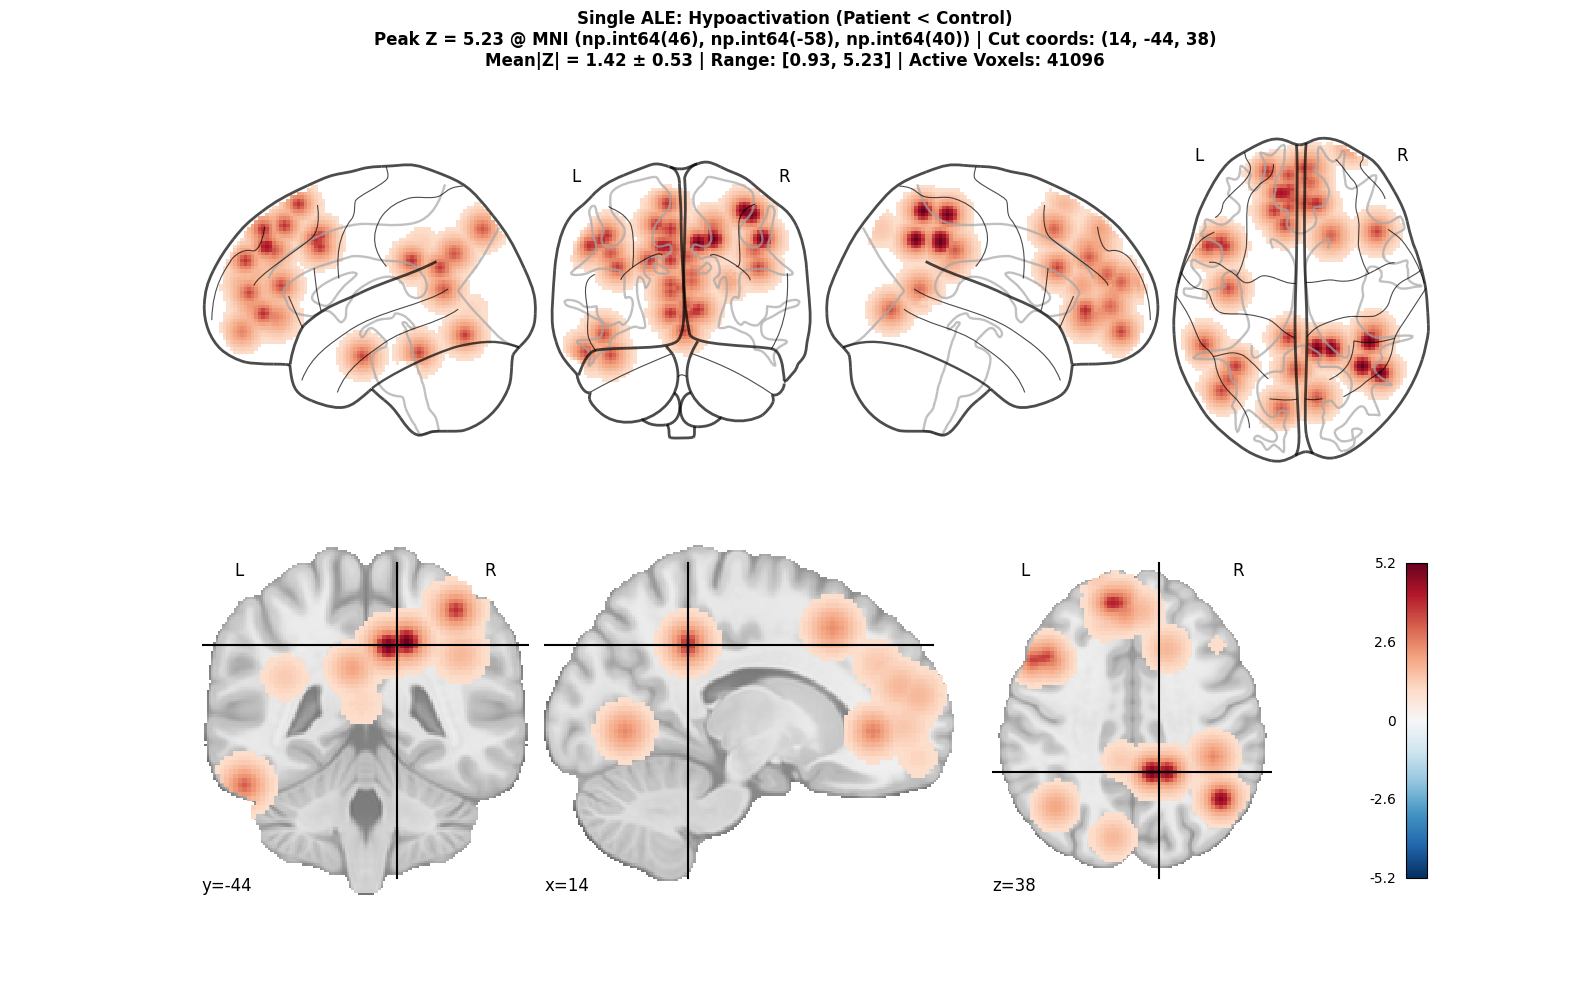


Single ALE: Hypoactivation (Patient < Control)
Peak Info:
  Z-value   : 5.232
  MNI coord : (np.int64(46), np.int64(-58), np.int64(40))

Z-value Statistics (non-zero voxels):
  Mean Z   : 1.420
  Std Dev  : 0.531
  Min Z    : 0.933
  Max Z    : 5.232
  N Voxels : 41096


In [8]:

# Improved visualization function: Glass brain + Orthogonal slices
from nilearn.datasets import load_mni152_template

def plot_unthresholded_map_improved(img_path, title, output_prefix=None, vmin=None, vmax=None, cut_coords=None):
    """
    Plot unthresholded statistical map:
    - Top: Glass brain (showing 3D distribution trends)
    - Bottom: Orthogonal slices (showing details) + colorbar
    
    cut_coords: if specified, use this MNI coordinate for the orthogonal slice;
                otherwise, automatically use the peak coordinate.
    """
    peak = get_peak_info(img_path)
    z_stats = get_z_statistics(img_path)
    
    # Load MNI template
    mni_template = load_mni152_template(resolution=1)
    
    # If vmin/vmax are not specified, use the peak value of the map
    if vmin is None or vmax is None:
        display_vmin = -np.abs(peak["peak_value"])
        display_vmax = np.abs(peak["peak_value"])
    else:
        display_vmin = vmin
        display_vmax = vmax
    
    # Determine cut_coords for orthogonal slices
    display_cut_coords = cut_coords if cut_coords is not None else peak["peak_mni"]
    
    # Create figure with two subplots
    fig = plt.figure(figsize=(16, 10))
    
    # ============ Top: Glass Brain ============
    ax1 = plt.subplot(2, 1, 1)
    
    # Plot glass brain
    display_glass = plotting.plot_glass_brain(
        img_path,
        display_mode="lyrz",
        colorbar=False,
        cmap="RdBu_r",
        title=None,
        black_bg=False,
        plot_abs=False,
        vmin=display_vmin,
        vmax=display_vmax,
        axes=ax1
    )
    
    # ============ Bottom: Orthogonal Slices ============
    ax2 = plt.subplot(2, 1, 2)
    
    display_ortho = plotting.plot_stat_map(
        img_path,
        bg_img=mni_template,
        display_mode="ortho",
        cut_coords=display_cut_coords,
        draw_cross=True,
        cmap="RdBu_r",
        colorbar=True,
        title=None,
        black_bg=False,
        vmin=display_vmin,
        vmax=display_vmax,
        axes=ax2
    )
    
    # Add title and statistical information
    fig.suptitle(
        f"{title}\n"
        f"Peak Z = {peak['peak_value']:.2f} @ MNI {peak['peak_mni']} | "
        f"Cut coords: {display_cut_coords}\n"
        f"Mean|Z| = {z_stats['mean']:.2f} ± {z_stats['std']:.2f} | "
        f"Range: [{z_stats['min']:.2f}, {z_stats['max']:.2f}] | "
        f"Active Voxels: {z_stats['n_voxels']}",
        fontsize=12, fontweight='bold', y=0.995
    )
    
    plt.tight_layout()
    
    if output_prefix:
        fig.savefig(f"{output_prefix}_improved.png", dpi=150, bbox_inches='tight')
        print(f"Saved: {output_prefix}_improved.png")
    
    plt.show()
    
    return peak, z_stats

# Plot individually and print statistical information

out_dir = "../3_Output/2_Contrast" 
os.makedirs(out_dir, exist_ok=True)

# Fixed cut_coords:
#   Patient > Control & Hyperactivation  → (52, 28, 16)
#   Control > Patient & Hypoactivation   → (46, -58, 40)
files_to_plot = [
    (patient_greater_control, "Contrast: Patient > Control",                    (52, 28, 16)),
    (control_greater_patient, "Contrast: Control > Patient",                    (14, -44, 38)),
    (ale_hyper,                   "Single ALE: Hyperactivation (Patient > Control)", (52, 28, 16)),
    (ale_hypo,                    "Single ALE: Hypoactivation (Patient < Control)",  (14, -44, 38)),
]

peak_results = {}

# Unified colorbar range: Use the global maximum Z value across all maps
all_peaks = []
for img_path, title, _ in files_to_plot:
    peak = get_peak_info(img_path)
    all_peaks.append(np.abs(peak["peak_value"]))

global_vmax = np.max(all_peaks)
global_vmin = -global_vmax

print(f"\nUnified display range: vmin={global_vmin:.2f}, vmax={global_vmax:.2f}\n")

for img_path, title, coords in files_to_plot:
    print(f"\n\nProcessing: {title}")
    print(f"Image: {img_path}")
    
    out_prefix = os.path.join(
        out_dir,
        title.replace(" ", "_").replace(":", "").replace(">", "gt").replace("<", "lt")
    )
    
    peak, z_stats = plot_unthresholded_map_improved(
        img_path=img_path,
        title=title,
        output_prefix=out_prefix,
        vmin=global_vmin,
        vmax=global_vmax,
        cut_coords=coords
    )
    peak_results[title] = {"peak": peak, "z_stats": z_stats}
    
    print(f"\n{'='*70}")
    print(f"{title}")
    print(f"{'='*70}")
    print(f"Peak Info:")
    print(f"  Z-value   : {peak['peak_value']:.3f}")
    print(f"  MNI coord : {peak['peak_mni']}")
    print(f"\nZ-value Statistics (non-zero voxels):")
    print(f"  Mean Z   : {z_stats['mean']:.3f}")
    print(f"  Std Dev  : {z_stats['std']:.3f}")
    print(f"  Min Z    : {z_stats['min']:.3f}")
    print(f"  Max Z    : {z_stats['max']:.3f}")
    print(f"  N Voxels : {z_stats['n_voxels']}")


## Visualization of Fail-Safe N (FSN) Maps


[Hyper and Hypoactivation] formula: img1 * img2 / 27
[Hyper and Hypoactivation] img_perc.shape: (91, 109, 91)


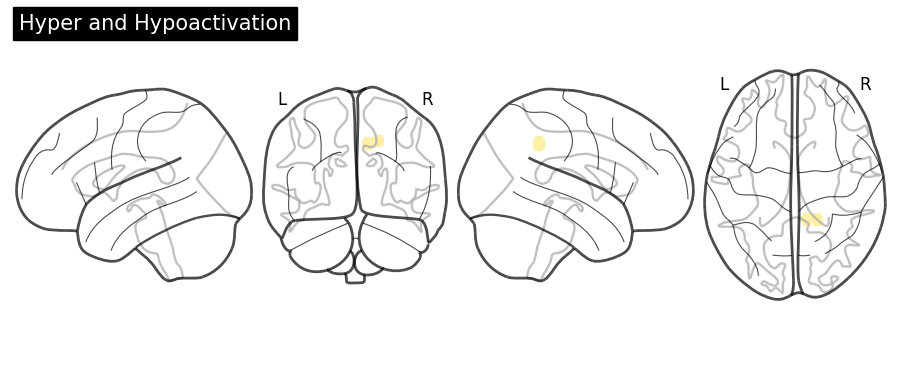

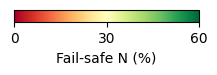

[Hypoactivation] formula: img1 * img2 / 18
[Hypoactivation] img_perc.shape: (91, 109, 91)


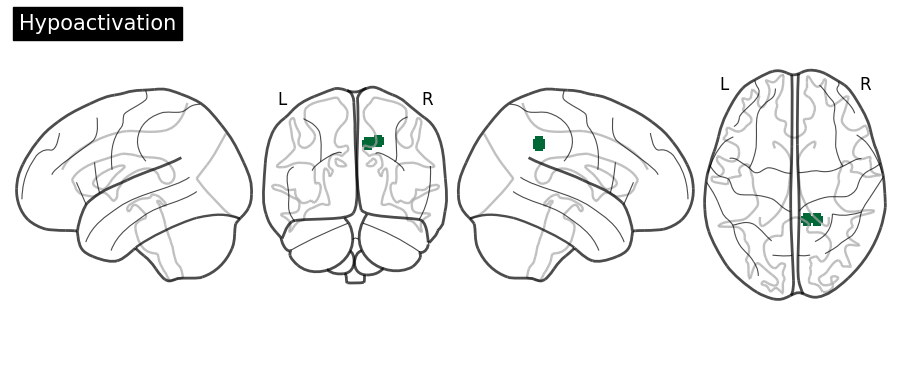

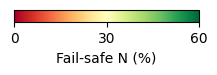

In [14]:
def plot_fsn_map(task_img_path, fsn_img_path, n_studies, title):
    # define the colorbar range for the FSN percentage  
    vmin, vmax = 0, 60 

    # load images and create mask
    img_task = image.load_img(task_img_path) 
    img_mask = image.math_img("np.where(img > 0, 100, 0)", img=img_task)  
    img_fsn = image.load_img(fsn_img_path) 

    # Calculate the FSN percentage
    formula = f"img1 * img2 / {n_studies}"  
    print(f'[{title}] formula: {formula}') 

    img_perc = image.math_img(formula=formula, img1=img_fsn, img2=img_mask)
    print(f'[{title}] img_perc.shape: {img_perc.shape}')

    # Plot glass brain
    p = plotting.plot_glass_brain(None, display_mode="lyrz", title=title)
    p.add_overlay(img_perc, cmap="RdYlGn", vmin=vmin, vmax=vmax)

    # Add colorbar
    fig = plt.figure(figsize=(12, 6)) 
    gs = fig.add_gridspec(110, 90) 
    ax_cbar = fig.add_subplot(gs[100:103, 36:54])
    cmap = plt.get_cmap("RdYlGn")
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    mpl.colorbar.ColorbarBase(
        ax_cbar,
        cmap=cmap,
        norm=norm,
        orientation="horizontal",
        ticks=[vmin, vmax, (vmin + vmax) / 2],
        label="Fail-safe N (%)",
    )
    plt.show()

# 1. Hyper and Hypo Activation FSN
plot_fsn_map(
    task_img_path="../3_Output/1_ALE/hyper_and_hypo_z_size_level_thresh.nii.gz",
    fsn_img_path="../3_Output/8_FSN/hyper_and_hypo/hyper_and_hypo_mean_fsn.nii.gz",
    n_studies=27,
    title="Hyper and Hypoactivation"
)

# 2. Hypoactivation FSN
plot_fsn_map(
    task_img_path="../3_Output/1_ALE/hypoactivation_z_size_level_thresh.nii.gz",
    fsn_img_path="../3_Output/8_FSN/hypoactivation/hypoactivation_mean_fsn.nii.gz",
    n_studies=18,
    title="Hypoactivation"
)